In [5]:
import torch
import torch.nn as nn

#### Naive 1D Convolution Implementation

In [2]:
import numpy as np


def conv1d(x, w, p=0, s=1):
    w_rot = np.array(w[::-1])
    x_padded = np.array(x)
    if p > 0:
        zero_pad = np.zeros(shape=p)
        x_padded = np.concatenate([zero_pad, x_padded, zero_pad])

    res = []
    for i in range(0, int((len(x_padded) - len(w_rot))) + 1, s):
        res.append(np.sum(x_padded[i : i + w_rot.shape[0]] * w_rot))

    return np.array(res)


## Testing:
x = [1, 3, 2, 4, 5, 6, 1, 3]
w = [1, 0, 3, 1, 2]
print("Conv1d Implementation: ", conv1d(x, w, p=2, s=1))

print("NumPy Results: ", np.convolve(x, w, mode="same"))

Conv1d Implementation:  [ 5. 14. 16. 26. 24. 34. 19. 22.]
NumPy Results:  [ 5 14 16 26 24 34 19 22]


#### Naive 2D Convolution Implementation

In [3]:
import scipy.signal


def conv2d(X, W, p=(0, 0), s=(1, 1)):
    W_rot = np.array(W)[::-1, ::-1]
    X_orig = np.array(X)
    n1 = X_orig.shape[0] + 2 * p[0]
    n2 = X_orig.shape[1] + 2 * p[1]

    # padding with zeroes
    X_padded = np.zeros(shape=(n1, n2))
    X_padded[p[0] : p[0] + X_orig.shape[0], p[1] : p[1] + X_orig.shape[1]] = X_orig

    res = []
    for i in range(0, int((X_padded.shape[0] - W_rot.shape[0]) / s[0]) + 1, s[0]):
        res.append([])
        for j in range(
            0, (int((X_padded.shape[1] - W_rot.shape[1]) / s[1]) + 1) * s[1], s[1]
        ):
            X_sub = X_padded[i : i + W_rot.shape[0], j : j + W_rot.shape[1]]
            res[-1].append(np.sum(X_sub * W_rot))

    return np.array(res)


X = [[1, 3, 2, 4], [5, 6, 1, 3], [1, 2, 0, 2], [3, 4, 3, 2]]
W = [[1, 0, 3], [1, 2, 1], [0, 1, 1]]

print("Conv2d Implementation:\n", conv2d(X, W, p=(1, 1), s=(1, 1)))
print("SciPy Results:\n", scipy.signal.convolve2d(X, W, mode="same"))

Conv2d Implementation:
 [[11. 25. 32. 13.]
 [19. 25. 24. 13.]
 [13. 28. 25. 17.]
 [11. 17. 14.  9.]]
SciPy Results:
 [[11 25 32 13]
 [19 25 24 13]
 [13 28 25 17]
 [11 17 14  9]]


---
## Implementing a deep CNN using PyTorch

In [ ]:
import torchvision
from torchvision import transforms

image_path = "./datasets/"
transform = transforms.Compose([transforms.ToTensor()])

mnist_dataset = torchvision.datasets.MNIST(
    root=image_path, train=True, transform=transform, download=True
)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:02<00:00, 4928006.84it/s]


Extracting ./MNIST/raw/train-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 121773.79it/s]


Extracting ./MNIST/raw/train-labels-idx1-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:01<00:00, 1212223.28it/s]


Extracting ./MNIST/raw/t10k-images-idx3-ubyte.gz to ./MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 11906580.48it/s]

Extracting ./MNIST/raw/t10k-labels-idx1-ubyte.gz to ./MNIST/raw



In [30]:
from torch.utils.data import Subset

# create a validation split
mnist_valid_dataset = Subset(mnist_dataset, torch.arange(10000))  # type: ignore
mnist_train_dataset = Subset(mnist_dataset, torch.arange(10000, len(mnist_dataset)))  # type: ignore
mnist_test_dataset = torchvision.datasets.MNIST(
    root=image_path, train=False, transform=transform, download=False
)

In [31]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64
torch.manual_seed(1)

train_dl = DataLoader(mnist_train_dataset, BATCH_SIZE, shuffle=True)
valid_dl = DataLoader(mnist_valid_dataset, BATCH_SIZE, shuffle=False)

In [32]:
model = nn.Sequential()
model.add_module(
    "conv1", nn.Conv2d(in_channels=1, out_channels=32, kernel_size=5, padding=2)
)
model.add_module("relu1", nn.ReLU())
model.add_module("pool1", nn.MaxPool2d(kernel_size=2))
model.add_module(
    "conv2", nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5, padding=2)
)
model.add_module("relu2", nn.ReLU())
model.add_module("pool2", nn.MaxPool2d(kernel_size=2))

In [33]:
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 64, 7, 7])

In [34]:
model.add_module("flatten", nn.Flatten())
x = torch.ones((4, 1, 28, 28))
model(x).shape

torch.Size([4, 3136])

In [35]:
model.add_module("fc1", nn.Linear(3136, 1024))
model.add_module("relu3", nn.ReLU())
model.add_module("dropout", nn.Dropout(p=0.5))
model.add_module("fc2", nn.Linear(1024, 10))

In [36]:
device = torch.device("cuda:0")
# device = torch.device("cpu")

model = model.to(device)

In [37]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [38]:
def train(model, num_epochs, train_dl, valid_dl):
    loss_hist_train = [0] * num_epochs
    accuracy_hist_train = [0] * num_epochs
    loss_hist_valid = [0] * num_epochs
    accuracy_hist_valid = [0] * num_epochs
    for epoch in range(num_epochs):
        model.train()
        for x_batch, y_batch in train_dl:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            pred = model(x_batch)
            loss = loss_fn(pred, y_batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_hist_train[epoch] += loss.item() * y_batch.size(0)
            is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
            accuracy_hist_train[epoch] += is_correct.sum().cpu()

        loss_hist_train[epoch] /= len(train_dl.dataset)
        accuracy_hist_train[epoch] /= len(train_dl.dataset)

        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in valid_dl:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                pred = model(x_batch)
                loss = loss_fn(pred, y_batch)
                loss_hist_valid[epoch] += loss.item() * y_batch.size(0)
                is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
                accuracy_hist_valid[epoch] += is_correct.sum().cpu()

        loss_hist_valid[epoch] /= len(valid_dl.dataset)
        accuracy_hist_valid[epoch] /= len(valid_dl.dataset)

        print(
            f"Epoch {epoch + 1} accuracy: {accuracy_hist_train[epoch]:.4f} val_accuracy: {accuracy_hist_valid[epoch]:.4f}"
        )
    return loss_hist_train, loss_hist_valid, accuracy_hist_train, accuracy_hist_valid

In [39]:
torch.manual_seed(1)
num_epochs = 20
hist = train(model, num_epochs, train_dl, valid_dl)

Epoch 1 accuracy: 0.9507 val_accuracy: 0.9827
Epoch 2 accuracy: 0.9839 val_accuracy: 0.9875
Epoch 3 accuracy: 0.9892 val_accuracy: 0.9829
Epoch 4 accuracy: 0.9918 val_accuracy: 0.9898
Epoch 5 accuracy: 0.9933 val_accuracy: 0.9910
Epoch 6 accuracy: 0.9948 val_accuracy: 0.9905
Epoch 7 accuracy: 0.9956 val_accuracy: 0.9893
Epoch 8 accuracy: 0.9963 val_accuracy: 0.9891
Epoch 9 accuracy: 0.9960 val_accuracy: 0.9909
Epoch 10 accuracy: 0.9967 val_accuracy: 0.9920
Epoch 11 accuracy: 0.9972 val_accuracy: 0.9913
Epoch 12 accuracy: 0.9972 val_accuracy: 0.9906
Epoch 13 accuracy: 0.9979 val_accuracy: 0.9920
Epoch 14 accuracy: 0.9978 val_accuracy: 0.9918
Epoch 15 accuracy: 0.9982 val_accuracy: 0.9898
Epoch 16 accuracy: 0.9982 val_accuracy: 0.9909
Epoch 17 accuracy: 0.9978 val_accuracy: 0.9908
Epoch 18 accuracy: 0.9977 val_accuracy: 0.9895
Epoch 19 accuracy: 0.9982 val_accuracy: 0.9915
Epoch 20 accuracy: 0.9986 val_accuracy: 0.9917


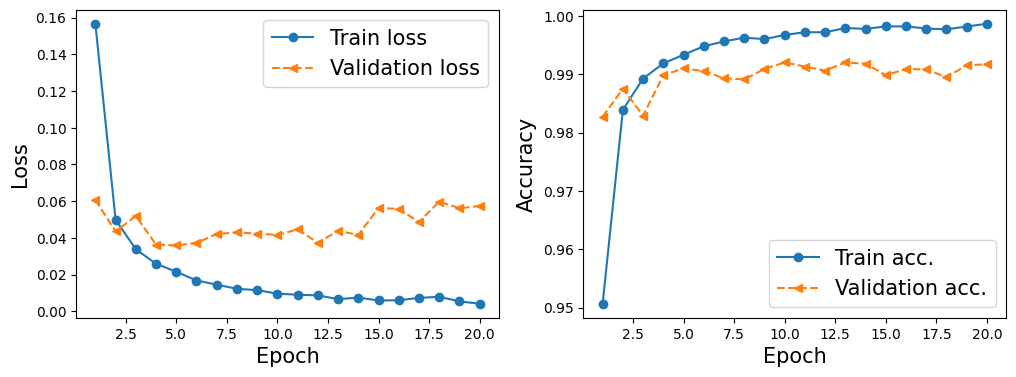

In [40]:
import matplotlib.pyplot as plt

x_arr = np.arange(len(hist[0])) + 1

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
ax.plot(x_arr, hist[0], "-o", label="Train loss")
ax.plot(x_arr, hist[1], "--<", label="Validation loss")
ax.set_xlabel("Epoch", size=15)
ax.set_ylabel("Loss", size=15)
ax.legend(fontsize=15)
ax = fig.add_subplot(1, 2, 2)
ax.plot(x_arr, hist[2], "-o", label="Train acc.")
ax.plot(x_arr, hist[3], "--<", label="Validation acc.")
ax.legend(fontsize=15)
ax.set_xlabel("Epoch", size=15)
ax.set_ylabel("Accuracy", size=15)

plt.show()

In [48]:
torch.cuda.synchronize()
# model_cpu = model.cpu()
pred = model(mnist_test_dataset.data.unsqueeze(1) / 255.0)
is_correct = (torch.argmax(pred, dim=1) == mnist_test_dataset.targets).float()
print(f"Test accuracy: {is_correct.mean():.4f}")

Test accuracy: 0.9928
